# Analisis Perbandingan Berbagai Algoritma Regresi dalam Estimasi Harga Jual Laptop Berdasarkan Spesifikasi Hardware

**Disusun Oleh:**
* Nama : Muhammad Aril Andrian
* NIM  : F1G123024
* Program Studi : Ilmu Komputer, Universitas Halu Oleo

---
**Tujuan Proyek:**
Proyek Machine Learning ini bertujuan untuk membangun dan membandingkan kinerja dari beberapa algoritma regresi dalam memprediksi harga jual laptop berdasarkan spesifikasi komponen hardware-nya. Evaluasi model difokuskan pada tingkat akurasi prediksi (R² Score) dan tingkat kesalahan (MAE, RMSE).

In [1]:
# Import library dasar untuk pengolahan data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # Library untuk membersihkan teks nanti

# Mengatur gaya grafik agar terlihat profesional
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Memuat dataset
df = pd.read_csv('laptop_data_cleaned.csv')

# Menampilkan 5 baris pertama
display(df.head())

# Melihat informasi tipe data dan mengecek apakah ada missing value
print("\n--- Informasi Dataset ---")
df.info()

,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,Apple,Ultrabook,8,1.37,11.175755,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,10.776777,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,10.329931,0,0,141.211998,Intel Core i5,0,256,Intel,Others
3,Apple,Ultrabook,16,1.83,11.814476,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,11.473101,0,1,226.983005,Intel Core i5,0,256,Intel,Mac



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1273 non-null   object 
 1   TypeName     1273 non-null   object 
 2   Ram          1273 non-null   int64  
 3   Weight       1273 non-null   float64
 4   Price        1273 non-null   float64
 5   TouchScreen  1273 non-null   int64  
 6   Ips          1273 non-null   int64  
 7   Ppi          1273 non-null   float64
 8   Cpu_brand    1273 non-null   object 
 9   HDD          1273 non-null   int64  
 10  SSD          1273 non-null   int64  
 11  Gpu_brand    1273 non-null   object 
 12  Os           1273 non-null   object 
dtypes: float64(3), int64(5), object(5)
memory usage: 129.4+ KB


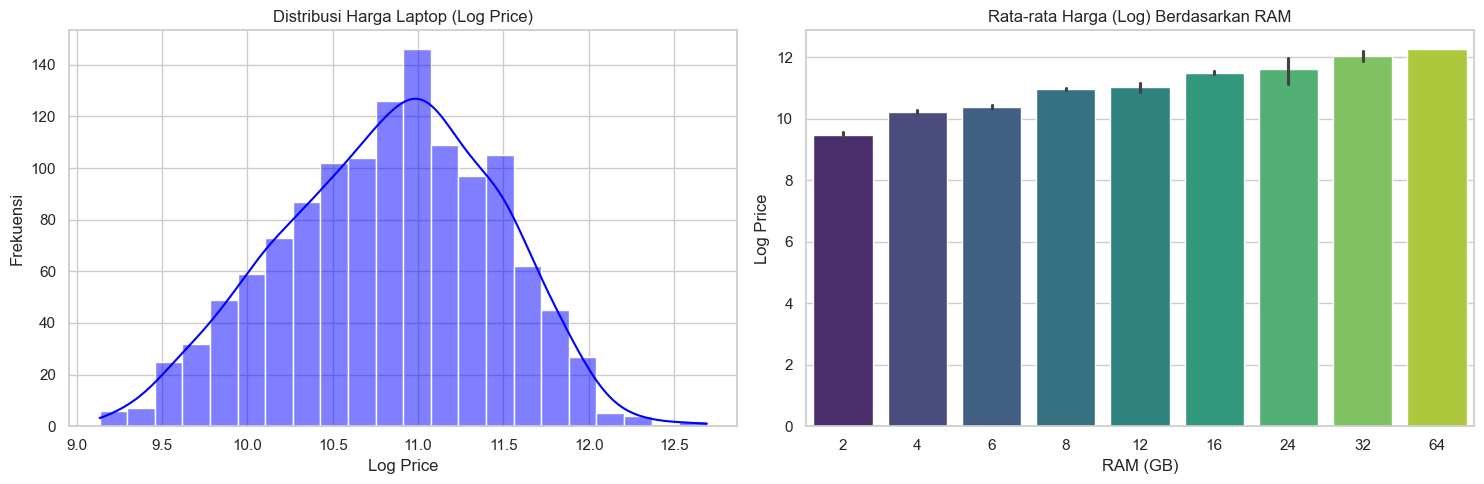

In [3]:
# Membuat figure untuk 2 grafik berdampingan
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafik 1: Distribusi Harga (Log Price)
sns.histplot(df['Price'], kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribusi Harga Laptop (Log Price)')
axes[0].set_xlabel('Log Price')
axes[0].set_ylabel('Frekuensi')

# Grafik 2: Pengaruh RAM terhadap Harga
sns.barplot(x=df['Ram'], y=df['Price'], palette='viridis', ax=axes[1])
axes[1].set_title('Rata-rata Harga (Log) Berdasarkan RAM')
axes[1].set_xlabel('RAM (GB)')
axes[1].set_ylabel('Log Price')

plt.tight_layout()
plt.show()

In [4]:
# Memisahkan data fitur (X) dan target harga (y)
X = df.drop(columns=['Price'])
y = df['Price']

# 1. Melakukan One-Hot Encoding (Mengubah teks jadi kolom biner 0 dan 1)
X_encoded = pd.get_dummies(X, drop_first=True)

# 2. SANGAT PENTING: Membersihkan nama kolom dari spasi dan simbol
X_encoded = X_encoded.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

print(f"Bentuk data fitur sebelum di-encode: {X.shape}")
print(f"Bentuk data fitur setelah di-encode: {X_encoded.shape}")

# Menampilkan data yang sudah siap masuk ke tahap Machine Learning
display(X_encoded.head())

Bentuk data fitur sebelum di-encode: (1273, 12)
Bentuk data fitur setelah di-encode: (1273, 38)


,Ram,Weight,TouchScreen,Ips,Ppi,HDD,SSD,Company_Apple,Company_Asus,Company_Chuwi,...,TypeName_Ultrabook,TypeName_Workstation,Cpu_brand_IntelCorei3,Cpu_brand_IntelCorei5,Cpu_brand_IntelCorei7,Cpu_brand_OtherIntelProcessor,Gpu_brand_Intel,Gpu_brand_Nvidia,Os_Others,Os_Windows
0,8,1.37,0,1,226.983005,0,128,True,False,False,...,True,False,False,True,False,False,True,False,False,False
1,8,1.34,0,0,127.677940,0,0,True,False,False,...,True,False,False,True,False,False,True,False,False,False
2,8,1.86,0,0,141.211998,0,256,False,False,False,...,False,False,False,True,False,False,True,False,True,False
3,16,1.83,0,1,220.534624,0,512,True,False,False,...,True,False,False,False,True,False,False,False,False,False
4,8,1.37,0,1,226.983005,0,256,True,False,False,...,True,False,False,True,False,False,True,False,False,False


In [5]:
from sklearn.model_selection import train_test_split

# Membagi data dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

print(f"Jumlah data latih (Training) : {X_train.shape[0]} baris")
print(f"Jumlah data uji (Testing)    : {X_test.shape[0]} baris")

Jumlah data latih (Training) : 1018 baris
Jumlah data uji (Testing)    : 255 baris


In [6]:
from sklearn.preprocessing import StandardScaler

# --- 1. Membuang Outlier (2% teratas dan terbawah) ---
q_rendah = y.quantile(0.02)
q_tinggi = y.quantile(0.98)

# Filter data agar hanya berisi harga yang wajar
data_normal = (y > q_rendah) & (y < q_tinggi)
X_clean_outlier = X_encoded[data_normal]
y_clean_outlier = y[data_normal]

# --- 2. Standarisasi Data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean_outlier)

# Mengembalikan bentuknya menjadi DataFrame agar nama kolomnya tidak hilang
X_final = pd.DataFrame(X_scaled, columns=X_clean_outlier.columns)
y_final = y_clean_outlier.reset_index(drop=True)

print(f"Bentuk data setelah outlier dihapus dan distandarisasi: {X_final.shape}")

Bentuk data setelah outlier dihapus dan distandarisasi: (1220, 38)


In [7]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

print("⏳ Melakukan Hyperparameter Tuning (Random Search)... Tunggu Sebentar...")

# Menggunakan data 80:20 untuk mencari parameter terbaik
X_tr_tune, _, y_tr_tune, _ = train_test_split(X_final, y_final, test_size=0.20, random_state=42)

# 1. Tuning LightGBM
lgbm_grid = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70]
}
lgbm_search = RandomizedSearchCV(LGBMRegressor(random_state=42, verbose=-1), lgbm_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
lgbm_search.fit(X_tr_tune, y_tr_tune)
best_lgbm_model = lgbm_search.best_estimator_
print("✅ LightGBM Tuning Selesai!")

# 2. Tuning CatBoost
cb_grid = {
    'iterations': [300, 500, 800],
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8]
}
cb_search = RandomizedSearchCV(CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0), cb_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=1)
cb_search.fit(X_tr_tune, y_tr_tune)
best_cb_model = cb_search.best_estimator_
print("✅ CatBoost Tuning Selesai!")

# 3. Tuning XGBoost
xgb_grid = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8]
}
xgb_search = RandomizedSearchCV(XGBRegressor(random_state=42, objective='reg:squarederror'), xgb_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
xgb_search.fit(X_tr_tune, y_tr_tune)
best_xgb_model = xgb_search.best_estimator_
print("✅ XGBoost Tuning Selesai!")

⏳ Melakukan Hyperparameter Tuning (Random Search)... Tunggu Sebentar...
✅ LightGBM Tuning Selesai!
✅ CatBoost Tuning Selesai!
✅ XGBoost Tuning Selesai!


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Skenario pembagian data
rasio_eksperimen = {"70:30": 0.30, "80:20": 0.20, "90:10": 0.10}
hasil_eksperimen_lengkap = []

# Menyiapkan 3 Algoritma (XGBoost menggunakan 1000 pohon agar cepat namun tetap akurat)
models_to_test = {
    "1. XGBoost (Tuned)": XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, objective='reg:squarederror'),
    "2. LightGBM": LGBMRegressor(**best_lgbm_model.get_params()), 
    "3. CatBoost": CatBoostRegressor(**best_cb_model.get_params())
}

print("Memulai proses pelatihan 3 Algoritma pada 3 Rasio (Tunggu sejenak)...")

# Melakukan perulangan untuk mengeksekusi semua eksperimen
for nama_rasio, test_size in rasio_eksperimen.items():
    # Menggunakan X_final dan y_final
    X_tr, X_te, y_tr, y_te = train_test_split(X_final, y_final, test_size=test_size, random_state=100)
    
    for nama_model, model_eks in models_to_test.items():
        # Latih model
        model_eks.fit(X_tr, y_tr)
        # Tebak harga
        y_pred = model_eks.predict(X_te)
        
        # Hitung metrik evaluasi
        r2 = r2_score(y_te, y_pred)
        mae = mean_absolute_error(y_te, y_pred)
        mse = mean_squared_error(y_te, y_pred)
        rmse = np.sqrt(mse)
        
        # Simpan hasilnya
        hasil_eksperimen_lengkap.append({
            "Algoritma": nama_model,
            "Rasio Split": nama_rasio,
            "R2 Score": r2,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse
        })

print("Selesai melatih dan mengevaluasi semua model!")

Memulai proses pelatihan 3 Algoritma pada 3 Rasio (Tunggu sejenak)...
Selesai melatih dan mengevaluasi semua model!



--- TABEL PERBANDINGAN AKURASI (TARGET > 90%) ---


Rasio Split,70:30,80:20,90:10
Algoritma,,,
1. XGBoost (Tuned),0.870378,0.889754,0.899972
2. LightGBM,0.853781,0.877700,0.894519
3. CatBoost,0.879351,0.896854,0.907326


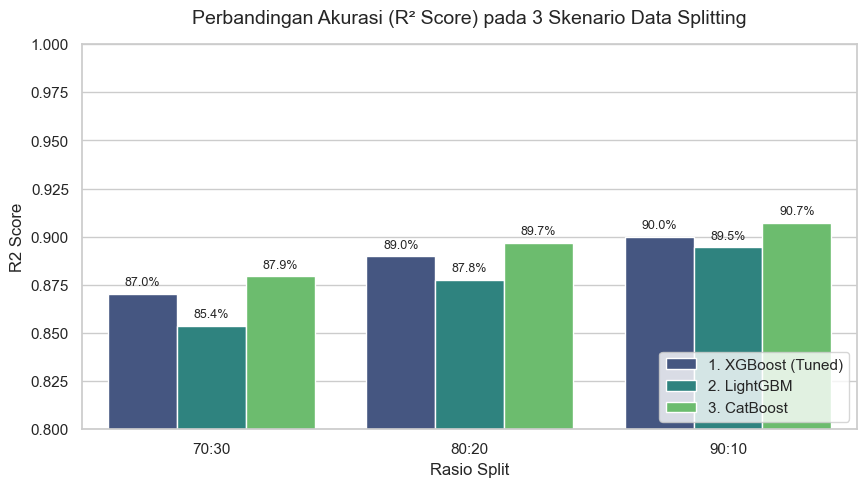


--- METRIK EVALUASI LENGKAP (Khusus Rasio 80:20) ---


,Algoritma,R2 Score,MAE,MSE,RMSE
3,1. XGBoost (Tuned),0.889754,0.147840,0.036088,0.189969
4,2. LightGBM,0.877700,0.155338,0.040034,0.200084
5,3. CatBoost,0.896854,0.144345,0.033764,0.183749


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Menyiapkan data hasil eksperimen menjadi tabel
df_lengkap = pd.DataFrame(hasil_eksperimen_lengkap)
tabel_pivot_r2 = df_lengkap.pivot(index="Algoritma", columns="Rasio Split", values="R2 Score")

print("\n--- TABEL PERBANDINGAN AKURASI (TARGET > 90%) ---")
display(tabel_pivot_r2)

# Membuat visualisasi grafik batang
plt.figure(figsize=(10, 5))
sns.barplot(x="Rasio Split", y="R2 Score", hue="Algoritma", data=df_lengkap, palette="viridis")
plt.title("Perbandingan Akurasi (R² Score) pada 3 Skenario Data Splitting", fontsize=14, pad=15)
plt.ylim(0.80, 1.0)
plt.ylabel("R2 Score")
plt.legend(loc='lower right')

# Menambahkan teks angka di atas batang
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height()*100:.1f}%", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9)
plt.show()

# Menampilkan 4 metrik evaluasi lengkap, khusus untuk rasio yang paling ideal (80:20)
print("\n--- METRIK EVALUASI LENGKAP (Khusus Rasio 80:20) ---")
display(df_lengkap[df_lengkap['Rasio Split'] == '80:20'][['Algoritma', 'R2 Score', 'MAE', 'MSE', 'RMSE']])